In [8]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [14]:
Books_Df = pd.read_csv("../data/raw/Books_raw.csv")

In [15]:
Books_Df

,Title,Category,Price,Rating,Availability,Description,UPC,Num_Reviews,Product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...
...,...,...,...,...,...,...,...,...,...
195,In Her Wake,Thriller,£12.84,1,In stock (19 available) In stock In stock In s...,A perfect life … until she discovered it wasn’...,23356462d1320d61,0,https://books.toscrape.com/catalogue/in-her-wa...
196,Sharp Objects,Mystery,£47.82,4,In stock (20 available) In stock In stock In s...,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,0,https://books.toscrape.com/catalogue/sharp-obj...
197,Soumission,Fiction,£50.10,1,In stock (20 available) In stock In stock,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760,0,https://books.toscrape.com/catalogue/soumissio...
198,Tipping the Velvet,Historical Fiction,£53.74,1,In stock (20 available) In stock,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,0,https://books.toscrape.com/catalogue/tipping-t...


In [17]:
Books_Df.shape

(200, 9)

In [19]:
Books_Df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Title         200 non-null    str  
 1   Category      200 non-null    str  
 2   Price         200 non-null    str  
 3   Rating        200 non-null    int64
 4   Availability  200 non-null    str  
 5   Description   199 non-null    str  
 6   UPC           200 non-null    str  
 7   Num_Reviews   200 non-null    int64
 8   Product_url   200 non-null    str  
dtypes: int64(2), str(7)
memory usage: 14.2 KB


In [27]:
Books_Df["Num_Reviews"].unique()

array([0])

So, as we can see that all reviews of books are zero. So we will drop that column because it is not help us to analyze anything. And also Product_url Column is also not helping us to analyze anything, so we will drop this as well.

In [20]:
df = Books_Df.drop(columns=["Num_Reviews", "Product_url"])

In [21]:
df

,Title,Category,Price,Rating,Availability,Description,UPC
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190
3,Olio,Poetry,£23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83
...,...,...,...,...,...,...,...
195,In Her Wake,Thriller,£12.84,1,In stock (19 available) In stock In stock In s...,A perfect life … until she discovered it wasn’...,23356462d1320d61
196,Sharp Objects,Mystery,£47.82,4,In stock (20 available) In stock In stock In s...,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48
197,Soumission,Fiction,£50.10,1,In stock (20 available) In stock In stock,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760
198,Tipping the Velvet,Historical Fiction,£53.74,1,In stock (20 available) In stock,"""Erotic and absorbing...Written with starling ...",90fa61229261140a


Now to check is there any null value, if yes then we will try to fix it.

In [28]:
df.isnull().sum()

Title           0
Category        0
Price           0
Rating          0
Availability    0
Description     1
UPC             0
dtype: int64

As there is one description is null we can replace will with no review or else. 

In [34]:
df["Description"] = df["Description"].fillna("No Description")

In [35]:
df["Description"].isnull().sum()

np.int64(0)

Now we will check is there is any duplicate values in data or not, so we can fix it.

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
#remove extra space from para
text_columns = ["Title", "Category", "Availability", "Description"]

for col in text_columns:
    df[col] = df[col].fillna("").str.strip()

Convert Price to Numeric

In [42]:
df["Price"] = (df["Price"].str.replace("£", "", regex=False).astype(float))

 Extract Stock Count

In [50]:
df["Stock_count"] = (df["Availability"].str.extract(r"(\d+)").astype(float))

In [53]:
df[["Availability", "Stock_count"]]

,Availability,Stock_count
0,In stock (19 available) In stock In stock In s...,19.0
1,In stock (19 available) In stock In stock In s...,19.0
2,In stock (19 available) In stock In stock In s...,19.0
3,In stock (19 available) In stock In stock In s...,19.0
4,In stock (19 available) In stock In stock In s...,19.0
...,...,...
195,In stock (19 available) In stock In stock In s...,19.0
196,In stock (20 available) In stock In stock In s...,20.0
197,In stock (20 available) In stock In stock,20.0
198,In stock (20 available) In stock,20.0


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         200 non-null    str    
 1   Category      200 non-null    str    
 2   Price         200 non-null    float64
 3   Rating        200 non-null    int64  
 4   Availability  200 non-null    str    
 5   Description   200 non-null    str    
 6   UPC           200 non-null    str    
 7   Stock_count   200 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 12.6 KB


In [28]:
#We remove pound sign , so that it can not give error in analyze part
df["Price"] = (df["Price"].astype(str).str.replace("£", "", regex=False))
df["Price"] = pd.to_numeric(df["Price"])

In [29]:
df["Price"].dtype

dtype('float64')

Feature Extraction

In [31]:
df["price_band"] = pd.cut(
    df["Price"],
    bins=[0, 20, 35, 50, float("inf")],
    labels=["Low", "Medium", "High", "Premium"]
)

In [32]:
df[["Price", "price_band"]].head()

,Price,price_band
0,45.17,High
1,51.33,Premium
2,37.59,High
3,23.88,Medium
4,57.25,Premium


Affordability Score

In [34]:
df["Affordability_score"] = (
    df["Price"].max() - df["Price"]
)

In [36]:
df["value_score"] = (
    df["Rating"] / df["Price"]
).round(3)

In [37]:
df["Rating"].dtype

dtype('int64')

In [38]:
#Create Reccommended feature
df["recommended"] = (
    (df["Rating"] >= 4) &
    (df["Price"] <= df["Price"].median())
)

In [39]:
df[["Title", "Rating", "Price", "recommended"]].head()

,Title,Rating,Price,recommended
0,It's Only the Himalayas,2,45.17,False
1,Libertarianism for Beginners,2,51.33,False
2,Mesaerion: The Best Science Fiction Stories 18...,1,37.59,False
3,Olio,1,23.88,False
4,Our Band Could Be Your Life: Scenes from the A...,3,57.25,False


In [41]:
df.to_csv("../data/processed/Books_cleaned.csv", index=False)

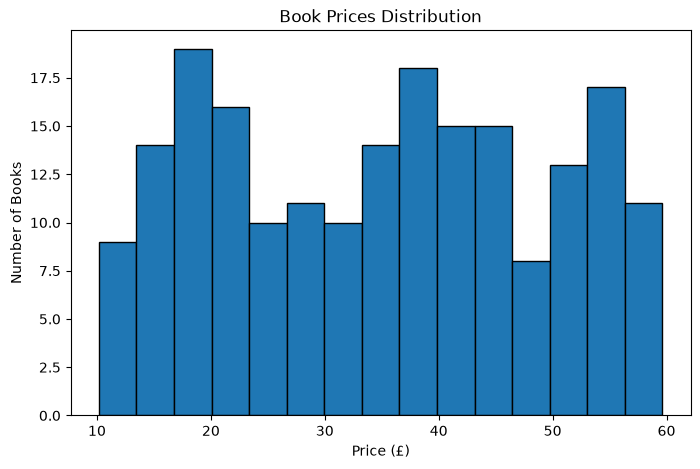

In [43]:
#Price Distribution
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=15, edgecolor="black")

plt.title("Book Prices Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.savefig("../plots/price_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

The Price Distribution Suggests that the online bookstore consist of affordable books with price as low as 10 pounds and premium books with price as high as 60 pounds.

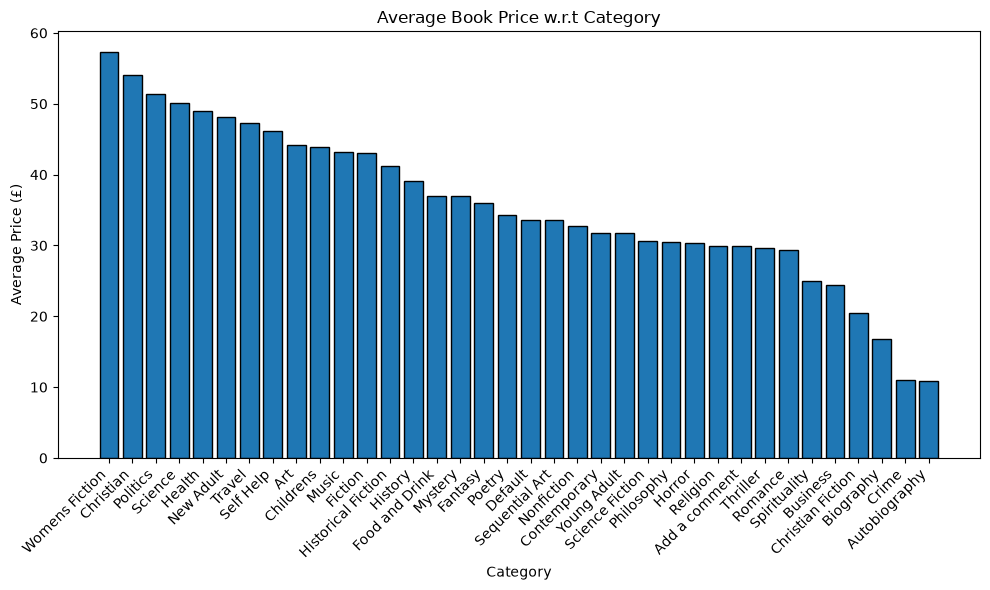

In [44]:
#Average Price By Category
avg_price = (
    df.groupby("Category")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    avg_price.index,
    avg_price.values,
    edgecolor="black"
)

plt.title("Average Book Price w.r.t Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../plots/average_price_by_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

The Category based Average price analysis suggests that categories such as women fiction, christian etc. have the highest average price while autobiographp, biography and crime have lowest average price which can help online bookstores to decide on pricing and discounts

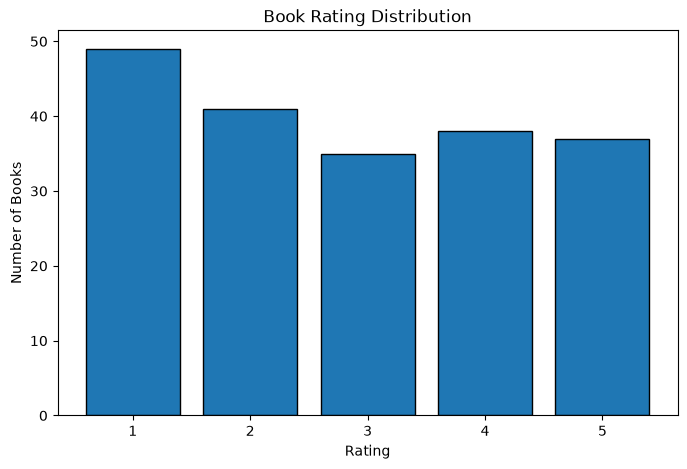

In [46]:
#Rating Distribution
plt.figure(figsize=(8,5))

rating_counts = df["Rating"].value_counts().sort_index()

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    edgecolor="black"
)

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.savefig("../plots/rating_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

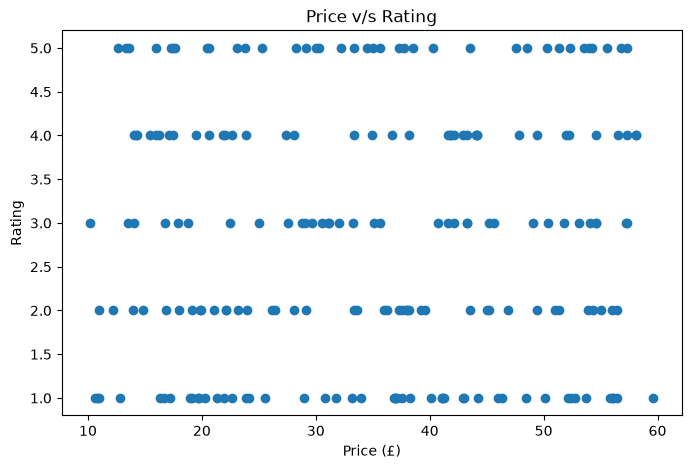

In [48]:
#Price vs Rating
plt.figure(figsize=(8,5))

plt.scatter(
    df["Price"],
    df["Rating"]
)

plt.title("Price v/s Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.savefig("../plots/price_vs_rating.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Only 38 out of 200 Books were reccomended and suggests that only a small amount of books offer a combination of high ratings and affordable prices